# Example 4 — Dielectron tridents at a stopped-pion source (SNS-like)

We compute the annual yield of neutrino-induced trident events
$$
\nu \;+\; N \;\longrightarrow\; \nu \;+\; e^-\;+\;e^+ \;+\; N
$$
for a Spallation Neutron Source (SNS)-like facility:

* $1\times10^{22}$ POT/year
* $0.1$ stopped $\pi^+$ per POT
* Two detectors at $20$ m, isotropic source: a 3-tonne **Argon-40** detector and a 3-tonne **C+H** (CH$_2$) detector

## Source: $\pi^+$DAR $+$ $\mu^+$DAR

The $\pi^+$ stops and decays via $\pi^+ \to \mu^+ \nu_\mu$, producing a monoenergetic $\nu_\mu$ at
$$
E_{\nu_\mu} = \frac{m_\pi^2 - m_\mu^2}{2\,m_\pi} \;\approx\; 29.79\,\text{MeV}.
$$
The resulting $\mu^+$ then stops and decays via $\mu^+ \to e^+ \nu_e \bar\nu_\mu$, with the standard Michel spectra (V$-$A, unpolarised) for $0 \le E \le m_\mu/2$:
$$
f_{\nu_e}(E) = \frac{96}{m_\mu^4} E^2 (m_\mu - 2E)\,, \qquad
f_{\bar\nu_\mu}(E) = \frac{16}{m_\mu^4} E^2 (3 m_\mu - 4 E).
$$
Both integrate to one neutrino per $\mu^+$ decay. So per stopped $\pi^+$ we get **one** monoenergetic $\nu_\mu$ plus **one** $\nu_e$ plus **one** $\bar\nu_\mu$ (no $\bar\nu_e$ at the source).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import neptune as nep
print('neptune', nep.__version__)

neptune 0.1.0


## 1) Source spectra and detector flux

We hold all primaries at rest, so the spectra are exactly the analytic forms above. The neutrino flux at the detector is geometrically diluted by $1/(4\pi R^2)$.

In [2]:
# Particle masses (GeV)
m_pi = 0.13957
m_mu = 0.10566
m_e  = 0.5109989e-3

# Source / exposure
POT_per_year = 1.0e22
pi_per_POT   = 0.10
N_pi_per_year = POT_per_year * pi_per_POT      # = 1e21 stopped pions per year

# Each stopped pi+ gives 1 nu_mu (mono) + 1 nu_e (Michel) + 1 nu_mu_bar (Michel)
N_nu_per_year_per_flavor = N_pi_per_year       # = 1e21 of each flavor per year

# Geometric flux at the detector at 20 m
R_cm = 20.0 * 100.0
geom_factor = 1.0 / (4.0 * np.pi * R_cm**2)    # 1 / cm^2 (per neutrino emitted)

# Per-flavor integrated flux at the detector [/cm^2/year]
Phi_total = N_nu_per_year_per_flavor * geom_factor
print(f'Per flavor: {N_nu_per_year_per_flavor:.2e} ν/yr emitted -> Φ = {Phi_total:.3e} ν/cm²/year at 20 m')

# Monoenergetic nu_mu energy from pi+ DAR
E_numu_DAR = (m_pi**2 - m_mu**2) / (2.0 * m_pi)
print(f'E(ν_μ) from π+ DAR = {E_numu_DAR*1e3:.3f} MeV')

# Michel endpoint
E_michel_max = m_mu / 2.0
print(f'Michel endpoint    = {E_michel_max*1e3:.3f} MeV')

Per flavor: 1.00e+21 ν/yr emitted -> Φ = 1.989e+13 ν/cm²/year at 20 m
E(ν_μ) from π+ DAR = 29.791 MeV
Michel endpoint    = 52.830 MeV


In [3]:
def michel_nu_e(E):
    """Normalized νe energy distribution from μ+ DAR [1/GeV]; ∫ dE = 1."""
    E = np.asarray(E, dtype=float)
    out = np.where(
        (E > 0) & (E < E_michel_max),
        96.0 / m_mu**4 * E**2 * (m_mu - 2.0 * E),
        0.0,
    )
    return out

def michel_nubar_mu(E):
    """Normalized ν̄μ energy distribution from μ+ DAR [1/GeV]; ∫ dE = 1."""
    E = np.asarray(E, dtype=float)
    out = np.where(
        (E > 0) & (E < E_michel_max),
        16.0 / m_mu**4 * E**2 * (3.0 * m_mu - 4.0 * E),
        0.0,
    )
    return out

# Sanity checks: spectra integrate to 1, average energies
Egrid = np.linspace(0, E_michel_max, 2000)
norm_e  = np.trapezoid(michel_nu_e(Egrid),  Egrid)
norm_mu = np.trapezoid(michel_nubar_mu(Egrid), Egrid)
Eavg_e  = np.trapezoid(Egrid * michel_nu_e(Egrid),  Egrid)
Eavg_mu = np.trapezoid(Egrid * michel_nubar_mu(Egrid), Egrid)
print(f'∫ f_νe   dE = {norm_e:.4f},  <E_νe>   = {Eavg_e*1e3:.2f} MeV')
print(f'∫ f_ν̄μ  dE = {norm_mu:.4f}, <E_ν̄μ>  = {Eavg_mu*1e3:.2f} MeV')
print(f'Expected:    <E_νe> = {3*m_mu/10*1e3:.2f} MeV, <E_ν̄μ> = {7*m_mu/20*1e3:.2f} MeV')

∫ f_νe   dE = 1.0000,  <E_νe>   = 31.70 MeV
∫ f_ν̄μ  dE = 0.9995, <E_ν̄μ>  = 36.95 MeV
Expected:    <E_νe> = 31.70 MeV, <E_ν̄μ> = 36.98 MeV


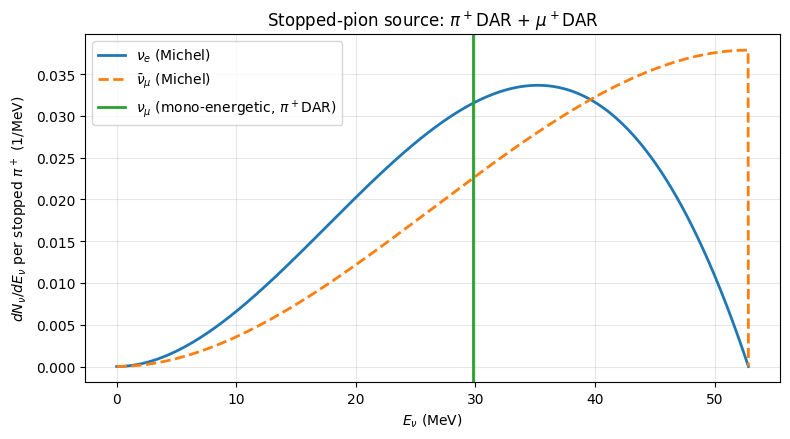

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
Egrid_mev = Egrid * 1000  # GeV -> MeV
ax.plot(Egrid_mev, michel_nu_e(Egrid)/1000.0, label=r'$\nu_e$ (Michel)', lw=2)
ax.plot(Egrid_mev, michel_nubar_mu(Egrid)/1000.0, label=r'$\bar\nu_\mu$ (Michel)', lw=2, ls='--')
ax.axvline(E_numu_DAR*1e3, color='C2', lw=2, label=r'$\nu_\mu$ (mono-energetic, $\pi^+$DAR)')
ax.set_xlabel(r'$E_\nu$ (MeV)')
ax.set_ylabel(r'$dN_\nu / dE_\nu$ per stopped $\pi^+$ (1/MeV)')
ax.set_title('Stopped-pion source: $\pi^+$DAR + $\mu^+$DAR')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

## 2) Detector targets

* **Detector A:** 3 t of $^{40}$Ar.
* **Detector B:** 3 t of CH$_2$ — equivalent to polyethylene scintillator. We split into independent C-12 and H-1 contributions and sum. For the lone proton (H-1) only the diffractive (nucleon-elastic) cross section makes sense, so we drop the coherent piece there.

In [5]:
Av = 6.022140857e23
M_DET = 3.0e6                          # 3 tonnes in grams

targets = {
    'Ar-40 (3 t)': dict(
        Z=18, A=40,
        N_nuclei=M_DET / 40.0 * Av,    # 4.52e28
        coherent=True, diffractive=True,
    ),
    'C-12 (3 t CH₂)': dict(
        # 1 C atom per CH2 molecule (M_mol = 14)
        Z=6, A=12,
        N_nuclei=M_DET / 14.0 * Av,    # 1.29e29
        coherent=True, diffractive=True,
    ),
    'H-1 (3 t CH₂)': dict(
        # 2 H atoms per CH2 molecule
        Z=1, A=1,
        N_nuclei=2.0 * M_DET / 14.0 * Av,  # 2.58e29
        coherent=False, diffractive=True,    # no coherent on a single proton
    ),
}
for name, t in targets.items():
    print(f'  {name:18s}: Z={t["Z"]:>2d} A={t["A"]:>2d} N={t["N_nuclei"]:.3e}')

  Ar-40 (3 t)       : Z=18 A=40 N=4.517e+28
  C-12 (3 t CH₂)    : Z= 6 A=12 N=1.290e+29
  H-1 (3 t CH₂)     : Z= 1 A= 1 N=2.581e+29


## 3) Cross sections and event rates

For each $(\nu\text{-flavor}, \text{target})$ pair we build a `TridentSMModel` for the dielectron channel ($\ell_1 = \ell_2 = e$) and compute
$$
N = \Phi_\text{tot}\,\sum_t N_\text{nuclei}^{(t)}\!\!\int dE_\nu\;f(E_\nu)\,\sigma^{(t)}(E_\nu),
$$
where $f(E_\nu)$ is the *normalised* spectrum (so $\int f\,dE = 1$) and $\Phi_\text{tot}$ is the total per-flavor flux at the detector. For the monoenergetic $\nu_\mu$ we just evaluate $\sigma$ at $E_\nu = 29.79$ MeV. For the Michel components we hand the spectrum to `TridentProcess` as `flux=...` and let `vegas` integrate.

In [6]:
def trident_sigma(target, nu_flavor, is_nubar=False, mode=('coherent', 'diffractive'),
                  Enu=None, flux=None, Emin=None, Emax=None,
                  nitn=8, neval=20_000):
    """
    Return the (flux-folded if flux is given) dielectron-trident cross section
    per nucleus [cm² · (flux units)] split into coherent and diffractive parts,
    summing over only the modes specified.
    """
    Z, A = target['Z'], target['A']
    model = nep.TridentSMModel(
        nu_flavor=nu_flavor, l1_flavor='e', l2_flavor='e', is_nubar=is_nubar,
    )
    proc = nep.TridentProcess(
        model, Z=Z, A=A,
        Enu=Enu, Emin=Emin, Emax=Emax, flux=flux,
        nitn=nitn, neval=neval,
    )
    coh = 0.0
    if 'coherent' in mode and target.get('coherent', True):
        coh = proc.sigma_coherent()[0]
    dif_per_proton = 0.0
    if 'diffractive' in mode and target.get('diffractive', True):
        dif_per_proton = proc.sigma_diffractive()[0]
    # Per-nucleus diffractive: Z protons (neutron mag. FF neglected)
    dif = Z * dif_per_proton if A > 1 else dif_per_proton
    return coh, dif

In [7]:
# Build the three flavor specifications
flavors = {
    'nu_mu (mono)':  dict(nu_flavor='mu',  is_nubar=False, mono=E_numu_DAR),
    'nu_e (Michel)': dict(nu_flavor='e',   is_nubar=False, mono=None,
                          flux=michel_nu_e,    Emin=1e-4, Emax=E_michel_max),
    'nubar_mu (Michel)': dict(nu_flavor='mu', is_nubar=True, mono=None,
                          flux=michel_nubar_mu, Emin=1e-4, Emax=E_michel_max),
}

rows = []
for fname, fspec in flavors.items():
    for tname, t in targets.items():
        if fspec['mono'] is not None:
            # Monoenergetic: σ at fixed Enu times Phi_total
            coh, dif = trident_sigma(
                t, nu_flavor=fspec['nu_flavor'], is_nubar=fspec['is_nubar'],
                Enu=fspec['mono'],
            )
        else:
            # Flux-folded: σ already includes the integral over E with Phi(E) (normalised → unit)
            coh, dif = trident_sigma(
                t, nu_flavor=fspec['nu_flavor'], is_nubar=fspec['is_nubar'],
                Enu=None, flux=fspec['flux'],
                Emin=fspec['Emin'], Emax=fspec['Emax'],
            )
        sigma_per_nucleus = coh + dif
        N_coh = Phi_total * t['N_nuclei'] * coh
        N_dif = Phi_total * t['N_nuclei'] * dif
        N_tot = N_coh + N_dif
        rows.append(dict(
            flavor=fname, target=tname, Z=t['Z'], A=t['A'],
            N_nuclei=t['N_nuclei'],
            sigma_coh=coh, sigma_dif=dif, sigma_tot=sigma_per_nucleus,
            N_coh=N_coh, N_dif=N_dif, N=N_tot,
        ))
df = pd.DataFrame(rows)
df

,flavor,target,Z,A,N_nuclei,sigma_coh,sigma_dif,sigma_tot,N_coh,N_dif,N
0,nu_mu (mono),Ar-40 (3 t),18,40,4.516606e+28,2.699681e-44,1.448474e-44,4.148155e-44,0.024258,0.013015,0.037273
1,nu_mu (mono),C-12 (3 t CH₂),6,12,1.290459e+29,4.548258e-45,4.548411e-45,9.096670e-45,0.011677,0.011677,0.023354
2,nu_mu (mono),H-1 (3 t CH₂),1,1,2.580918e+29,0.000000e+00,5.396012e-46,5.396012e-46,0.000000,0.002771,0.002771
3,nu_e (Michel),Ar-40 (3 t),18,40,4.516606e+28,1.293573e-43,7.059286e-44,1.999502e-43,0.116234,0.063431,0.179665
4,nu_e (Michel),C-12 (3 t CH₂),6,12,1.290459e+29,2.191426e-44,2.214103e-44,4.405529e-44,0.056260,0.056842,0.113103
5,nu_e (Michel),H-1 (3 t CH₂),1,1,2.580918e+29,0.000000e+00,2.631638e-45,2.631638e-45,0.000000,0.013512,0.013512
6,nubar_mu (Michel),Ar-40 (3 t),18,40,4.516606e+28,3.528285e-44,1.865308e-44,5.393593e-44,0.031703,0.016761,0.048464
7,nubar_mu (Michel),C-12 (3 t CH₂),6,12,1.290459e+29,5.928289e-45,5.852913e-45,1.178120e-44,0.015220,0.015026,0.030246
8,nubar_mu (Michel),H-1 (3 t CH₂),1,1,2.580918e+29,0.000000e+00,6.933851e-46,6.933851e-46,0.000000,0.003560,0.003560


### Per-detector totals

In [8]:
# Map target -> detector
detector_of = {
    'Ar-40 (3 t)':    'Ar (3 t)',
    'C-12 (3 t CH₂)': 'CH₂ (3 t)',
    'H-1 (3 t CH₂)':  'CH₂ (3 t)',
}
df['detector'] = df['target'].map(detector_of)
by_detector = df.groupby(['detector', 'flavor'])['N'].sum().unstack('flavor').fillna(0.0)
by_detector['total'] = by_detector.sum(axis=1)
by_detector.style.format('{:.3e}')

flavor,nu_e (Michel),nu_mu (mono),nubar_mu (Michel),total
detector,,,,
Ar (3 t),1.797e-01,3.727e-02,4.846e-02,2.654e-01
CH₂ (3 t),1.266e-01,2.612e-02,3.381e-02,1.865e-01


In [9]:
totals = df.groupby('detector')['N'].sum()
for det, n in totals.items():
    print(f'{det:14s} -> {n:.3e} dielectron trident events / year')

Ar (3 t)       -> 2.654e-01 dielectron trident events / year
CH₂ (3 t)      -> 1.865e-01 dielectron trident events / year


## 4) Where the events come from

Bar chart of the events per (detector, target, flavor).

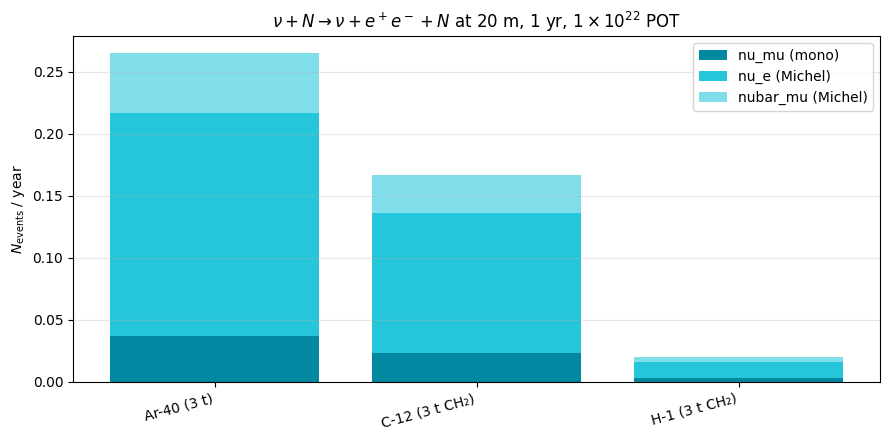

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = []
data = {f: [] for f in flavors}
for tname in targets:
    labels.append(tname)
    for fname in flavors:
        sel = df[(df['target'] == tname) & (df['flavor'] == fname)]
        data[fname].append(float(sel['N'].iloc[0]))
x = np.arange(len(labels))
bottom = np.zeros(len(labels))
colors = {'nu_mu (mono)': '#0288a1', 'nu_e (Michel)': '#26c6da', 'nubar_mu (Michel)': '#80deea'}
for fname, vals in data.items():
    ax.bar(x, vals, bottom=bottom, label=fname, color=colors[fname])
    bottom += np.array(vals)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel(r'$N_\mathrm{events}$ / year')
ax.set_title(r'$\nu + N \to \nu + e^+ e^- + N$ at 20 m, 1 yr, $1\times10^{22}$ POT')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()

## 5) Compare with LSND

LSND (Liquid Scintillator Neutrino Detector at LANSCE/LAMPF) was the canonical $\pi^+/\mu^+$ DAR experiment. We re-run the same calculation with the LSND parameters:

* $N_\text{POT}$ (full run, 1993–1998): $\approx 1.8 \times 10^{23}$
* $\pi^+$ per POT: $\approx 0.07$
* Detector: 167 t of mineral oil ($\approx$ CH$_2$ by composition)
* Distance from source to detector: $\approx 30$ m

(Numbers from Aguilar et al., *Phys. Rev. D* **64** (2001) 112007.)

In [11]:
# === LSND parameters ===
POT_LSND       = 1.8e23
pi_per_POT_LSND = 0.07
M_det_LSND     = 167.0 * 1e6      # 167 tonnes -> grams
R_cm_LSND      = 30.0 * 100.0     # 30 m -> cm

# Total ν per flavor at the source (one νμ + one νe + one ν̄μ per stopped π+)
N_nu_LSND = POT_LSND * pi_per_POT_LSND
Phi_LSND  = N_nu_LSND / (4.0 * np.pi * R_cm_LSND**2)

# Mineral oil ≈ CH₂: per CH2 'molecule' (M = 14 g/mol) we get 1 C + 2 H
lsnd_targets = {
    'C-12 (LSND mineral oil)': dict(
        Z=6, A=12,
        N_nuclei=M_det_LSND / 14.0 * Av,
        coherent=True, diffractive=True,
    ),
    'H-1 (LSND mineral oil)':  dict(
        Z=1, A=1,
        N_nuclei=2.0 * M_det_LSND / 14.0 * Av,
        coherent=False, diffractive=True,
    ),
}
print(f'LSND total ν / flavor:    {N_nu_LSND:.2e}')
print(f'LSND Φ at 30 m / flavor:  {Phi_LSND:.3e} ν/cm^2 (over the run)')
for name, t in lsnd_targets.items():
    print(f"  {name:25s}: Z={t['Z']:>2d} A={t['A']:>2d} N={t['N_nuclei']:.3e}")

LSND total ν / flavor:    1.26e+22
LSND Φ at 30 m / flavor:  1.114e+14 ν/cm^2 (over the run)
  C-12 (LSND mineral oil)  : Z= 6 A=12 N=7.184e+30
  H-1 (LSND mineral oil)   : Z= 1 A= 1 N=1.437e+31


In [12]:
rows_lsnd = []
for fname, fspec in flavors.items():
    for tname, t in lsnd_targets.items():
        if fspec['mono'] is not None:
            coh, dif = trident_sigma(
                t, nu_flavor=fspec['nu_flavor'], is_nubar=fspec['is_nubar'],
                Enu=fspec['mono'],
            )
        else:
            coh, dif = trident_sigma(
                t, nu_flavor=fspec['nu_flavor'], is_nubar=fspec['is_nubar'],
                Enu=None, flux=fspec['flux'],
                Emin=fspec['Emin'], Emax=fspec['Emax'],
            )
        sigma_per_nucleus = coh + dif
        N_coh = Phi_LSND * t['N_nuclei'] * coh
        N_dif = Phi_LSND * t['N_nuclei'] * dif
        N_tot = N_coh + N_dif
        rows_lsnd.append(dict(
            flavor=fname, target=tname, Z=t['Z'], A=t['A'],
            N_nuclei=t['N_nuclei'],
            sigma_coh=coh, sigma_dif=dif, sigma_tot=sigma_per_nucleus,
            N_coh=N_coh, N_dif=N_dif, N=N_tot,
        ))
df_lsnd = pd.DataFrame(rows_lsnd)
df_lsnd

,flavor,target,Z,A,N_nuclei,sigma_coh,sigma_dif,sigma_tot,N_coh,N_dif,N
0,nu_mu (mono),C-12 (LSND mineral oil),6,12,7.183554e+30,4.547362e-45,4.562459e-45,9.109821e-45,3.639293,3.651375,7.290669
1,nu_mu (mono),H-1 (LSND mineral oil),1,1,1.436711e+31,0.000000e+00,5.405961e-46,5.405961e-46,0.000000,0.865287,0.865287
2,nu_e (Michel),C-12 (LSND mineral oil),6,12,7.183554e+30,2.191009e-44,2.212382e-44,4.403391e-44,17.534832,17.705884,35.240716
3,nu_e (Michel),H-1 (LSND mineral oil),1,1,1.436711e+31,0.000000e+00,2.623572e-45,2.623572e-45,0.000000,4.199334,4.199334
4,nubar_mu (Michel),C-12 (LSND mineral oil),6,12,7.183554e+30,5.925757e-45,5.842950e-45,1.176871e-44,4.742435,4.676163,9.418598
5,nubar_mu (Michel),H-1 (LSND mineral oil),1,1,1.436711e+31,0.000000e+00,6.931541e-46,6.931541e-46,0.000000,1.109474,1.109474


In [13]:
by_flavor_lsnd = df_lsnd.groupby('flavor')['N'].sum()
by_target_lsnd = df_lsnd.groupby('target')['N'].sum()
total_lsnd = df_lsnd['N'].sum()
print('=== LSND full-run dielectron trident yield ===')
for fl, n in by_flavor_lsnd.items():
    print(f'  {fl:20s} -> {n:.3e}')
print('--')
for tg, n in by_target_lsnd.items():
    print(f'  {tg:25s} -> {n:.3e}')
print('--')
print(f'  TOTAL                     -> {total_lsnd:.3e} dielectron trident events')

=== LSND full-run dielectron trident yield ===
  nu_e (Michel)        -> 3.944e+01
  nu_mu (mono)         -> 8.156e+00
  nubar_mu (Michel)    -> 1.053e+01
--
  C-12 (LSND mineral oil)   -> 5.195e+01
  H-1 (LSND mineral oil)    -> 6.174e+00
--
  TOTAL                     -> 5.812e+01 dielectron trident events


## 6) Comparison with $\nu$-electron elastic scattering

At a stopped-pion source, $\nu$-electron elastic scattering ($\nu + e^- \to \nu + e^-$) produces a much larger event rate than dielectron trident, because:

1. **Phase space.** Elastic is a $2\to 2$ process, $\sigma \propto G_F^2 m_e E_\nu$; trident is $2\to 4$, suppressed by an extra factor $\alpha^2 (E_\nu / \Lambda)^4$ with $\Lambda$ a hadronic scale.
2. **Targets.** Elastic counts atomic *electrons* ($Z$ per atom, ~$10^{30}$ in 3 t of Ar); trident counts *nucleons/nuclei*. For coherent trident the $Z^2$ enhancement helps but doesn't overcome the kinematic suppression.

First we plot the cross sections per Argon atom on the same axes (elastic times $Z=18$ to bring it to the per-atom level), for the SM dielectron channel.

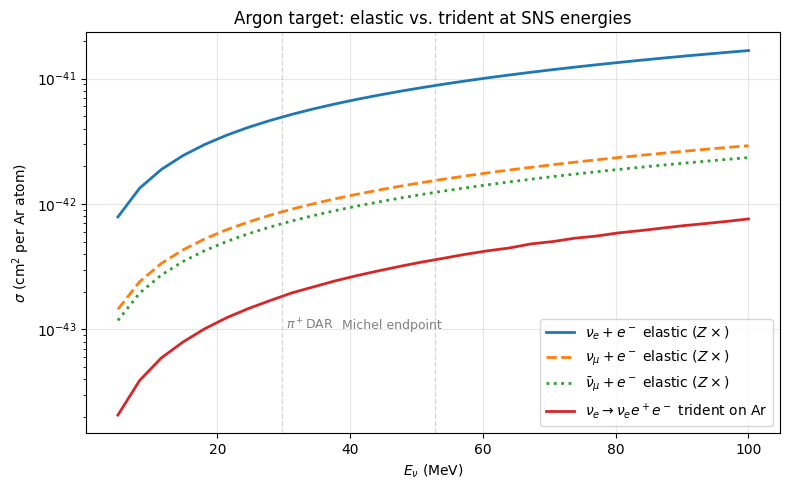

In [14]:
Egrid_xs = np.linspace(0.005, 0.100, 30)   # 5–100 MeV
Z_Ar, A_Ar = 18, 40

# Trident on Ar (per nucleus, summed coh + Z*diff)
sig_trident_Ar = np.zeros_like(Egrid_xs)
for i, E in enumerate(Egrid_xs):
    m = nep.TridentSMModel(nu_flavor='e', l1_flavor='e', l2_flavor='e')
    p = nep.TridentProcess(m, Z=Z_Ar, A=A_Ar, Enu=E, nitn=4, neval=4_000)
    res = p.sigma_total()
    sig_trident_Ar[i] = res['total_per_nucleus'][0]

# nu-e elastic, per electron, for each flavor
sm_e   = nep.NuElectronSMModel(nu_flavor='e',  is_nubar=False)
sm_mu  = nep.NuElectronSMModel(nu_flavor='mu', is_nubar=False)
sm_mub = nep.NuElectronSMModel(nu_flavor='mu', is_nubar=True)
sig_e_per_e   = np.array([sm_e.total_xsec(E)   for E in Egrid_xs])
sig_mu_per_e  = np.array([sm_mu.total_xsec(E)  for E in Egrid_xs])
sig_mub_per_e = np.array([sm_mub.total_xsec(E) for E in Egrid_xs])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Egrid_xs*1e3, Z_Ar * sig_e_per_e,   label=r'$\nu_e + e^-$ elastic ($Z\times$)', lw=2, color='C0')
ax.plot(Egrid_xs*1e3, Z_Ar * sig_mu_per_e,  label=r'$\nu_\mu + e^-$ elastic ($Z\times$)', lw=2, color='C1', ls='--')
ax.plot(Egrid_xs*1e3, Z_Ar * sig_mub_per_e, label=r'$\bar\nu_\mu + e^-$ elastic ($Z\times$)', lw=2, color='C2', ls=':')
ax.plot(Egrid_xs*1e3, sig_trident_Ar,        label=r'$\nu_e \to \nu_e e^+e^-$ trident on Ar', lw=2, color='C3')
ax.set_xlabel(r'$E_\nu$ (MeV)')
ax.set_ylabel(r'$\sigma$ (cm$^2$ per Ar atom)')
ax.set_yscale('log')
ax.axvline(E_numu_DAR*1e3, color='gray', alpha=0.3, lw=1, ls='--')
ax.text(E_numu_DAR*1e3 + 0.5, 1e-43, r'$\pi^+$DAR', color='gray', fontsize=9)
ax.axvline(E_michel_max*1e3, color='gray', alpha=0.3, lw=1, ls='--')
ax.text(E_michel_max*1e3 - 14, 1e-43, r'Michel endpoint', color='gray', fontsize=9)
ax.set_title(r'Argon target: elastic vs. trident at SNS energies')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()

In [15]:
# === ν-e elastic event rates at all three detector configurations ===
# Number of atomic electrons per detector (= Z × N_nuclei summed over targets)
configs = {
    'Ar (3 t, SNS, 1 yr)':  dict(Phi=Phi_total, N_e={'Ar': 18 * 4.516606e+28}),
    'CH₂ (3 t, SNS, 1 yr)': dict(Phi=Phi_total, N_e={'C': 6 * 1.290459e+29,
                                                       'H': 1 * 2.580918e+29}),
    'CH₂ (167 t, LSND full run)': dict(Phi=Phi_LSND, N_e={'C': 6 * 7.183554e+30,
                                                            'H': 1 * 1.436711e+31}),
}

elastic_specs = {
    'nu_mu (mono)':       dict(model=sm_mu,  mono=E_numu_DAR, flux=None),
    'nu_e (Michel)':      dict(model=sm_e,   mono=None, flux=michel_nu_e),
    'nubar_mu (Michel)':  dict(model=sm_mub, mono=None, flux=michel_nubar_mu),
}

rows_el = []
for cname, cfg in configs.items():
    N_e_total = sum(cfg['N_e'].values())
    for fname, fspec in elastic_specs.items():
        if fspec['mono'] is not None:
            sigma = fspec['model'].total_xsec(fspec['mono'])
        else:
            proc = nep.NuElectronProcess(
                fspec['model'],
                Emin=1e-4, Emax=E_michel_max,
                flux=fspec['flux'],
            )
            sigma = proc.flux_avg_xsec()      # ∫ σ(E) f(E) dE since ∫f dE = 1
        N_evt = cfg['Phi'] * N_e_total * sigma
        rows_el.append(dict(detector=cname, flavor=fname,
                            N_electrons=N_e_total, sigma=sigma, N=N_evt))
df_el = pd.DataFrame(rows_el)
df_el

,detector,flavor,N_electrons,sigma,N
0,"Ar (3 t, SNS, 1 yr)",nu_mu (mono),8.129891e+29,4.830474e-44,0.781276
1,"Ar (3 t, SNS, 1 yr)",nu_e (Michel),8.129891e+29,2.929965e-43,4.738898
2,"Ar (3 t, SNS, 1 yr)",nubar_mu (Michel),8.129891e+29,4.814986e-44,0.778771
3,"CH₂ (3 t, SNS, 1 yr)",nu_mu (mono),1.032367e+30,4.830474e-44,0.992097
4,"CH₂ (3 t, SNS, 1 yr)",nu_e (Michel),1.032367e+30,2.929965e-43,6.017649
5,"CH₂ (3 t, SNS, 1 yr)",nubar_mu (Michel),1.032367e+30,4.814986e-44,0.988916
6,"CH₂ (167 t, LSND full run)",nu_mu (mono),5.746843e+31,4.830474e-44,309.269624
7,"CH₂ (167 t, LSND full run)",nu_e (Michel),5.746843e+31,2.929965e-43,1875.901543
8,"CH₂ (167 t, LSND full run)",nubar_mu (Michel),5.746843e+31,4.814986e-44,308.277999


In [16]:
# Pivot to (detector × flavor) for a clean comparison table
pivot = df_el.pivot(index='detector', columns='flavor', values='N')
pivot['total ν-e elastic'] = pivot.sum(axis=1)

# Add a column with the corresponding e+e- trident totals computed earlier
trident_totals = {
    'Ar (3 t, SNS, 1 yr)':         df[df['detector'] == 'Ar (3 t)']['N'].sum(),
    'CH₂ (3 t, SNS, 1 yr)':        df[df['detector'] == 'CH₂ (3 t)']['N'].sum(),
    'CH₂ (167 t, LSND full run)':  df_lsnd['N'].sum(),
}
pivot['e+e- trident total'] = pd.Series(trident_totals)
pivot['ratio (elastic / trident)'] = pivot['total ν-e elastic'] / pivot['e+e- trident total']
pivot.style.format({c: '{:.3e}' for c in pivot.columns})

flavor,nu_e (Michel),nu_mu (mono),nubar_mu (Michel),total ν-e elastic,e+e- trident total,ratio (elastic / trident)
detector,,,,,,
"Ar (3 t, SNS, 1 yr)",4.739e+00,7.813e-01,7.788e-01,6.299e+00,2.654e-01,2.373e+01
"CH₂ (167 t, LSND full run)",1.876e+03,3.093e+02,3.083e+02,2.493e+03,5.812e+01,4.290e+01
"CH₂ (3 t, SNS, 1 yr)",6.018e+00,9.921e-01,9.889e-01,7.999e+00,1.865e-01,4.288e+01


## 7) Notes

* Spectra are normalised so $\int f\,dE = 1$ per stopped $\pi^+$ (one $\nu_\mu$ + one $\nu_e$ + one $\bar\nu_\mu$).
* The detector is treated as a point at $20$ m, with isotropic source — geometric flux is $1/(4\pi R^2)$.
* The dominant contribution is from $\nu_e$ on Argon: at $E_\nu \sim m_\mu/2$ the CC interference makes the dielectron channel $\sim 6\times$ larger than the NC-only $\nu_\mu$/$\bar\nu_\mu$ channels, and Argon's $Z^2 = 324$ enhances the coherent piece.
* For the H-1 target only the nucleon-elastic ("diffractive") channel is physical, so the coherent piece is dropped there.
* These are SM expectations; pass `nep.TridentBSMModel(..., mzprime=..., gV_prime=..., CHARGE=Z)` to scan a $Z'$ that couples to neutrinos and electrons.
* All numbers are pure tree-level cross-section predictions: no detection efficiency, fiducial cuts, or background subtraction.